In [ ]:
#  Session Starter
from google.colab import drive
drive.mount('/content/drive')

import os, json, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

DRIVE_PATH = '/content/drive/MyDrive/anemia_project'
models_dir = os.path.join(DRIVE_PATH, 'models')

# Re-extract dataset
if not os.path.exists('/content/fresh_dataset/dataset anemia/Italy'):
    print("Extracting...")
    !apt-get install -y p7zip-full -q
    !7z x /content/drive/MyDrive/anemia_project/dataset_clean.zip \
          -o/content/fresh_dataset -y

# Load best MobileNetV2 model
print("Loading best MobileNetV2 model...")
model = tf.keras.models.load_model(
    os.path.join(models_dir, 'mobilenet_final.keras'))

print(f"Model loaded!")
print(f"Input shape  : {model.input_shape}")
print(f"Output shape : {model.output_shape}")
print()

# Load image labels
with open(os.path.join(DRIVE_PATH, 'image_labels.json'), 'r') as f:
    image_label_dict = json.load(f)

# Load split info to get test images
with open(os.path.join(DRIVE_PATH, 'split_info.json'), 'r') as f:
    split_info = json.load(f)

test_paths  = split_info['test_paths']
test_labels = split_info['test_labels']

print(f"Test images  : {len(test_paths)}")
print(f"  Anemic     : {sum(test_labels)}")
print(f"  Normal     : {test_labels.count(0)}")
print()
print("Italy : True")
print("Ready for Grad-CAM!")

Mounted at /content/drive
Extracting...
Reading package lists...
Building dependency tree...
Reading state information...
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/anemia_project/                                                1 file, 666269625 bytes (636 MiB)

Extracting archive: /content/drive/MyDrive/anemia_project/dataset_clean.zip
--
Path = /content/drive/MyDrive/anemia_project/dataset_clean.zip
Type = zip
Physical Size = 666269625

  0%      2% 17 - dataset anemia/India/13/20200203_190841.jpg

Last conv layer: Conv_1



/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


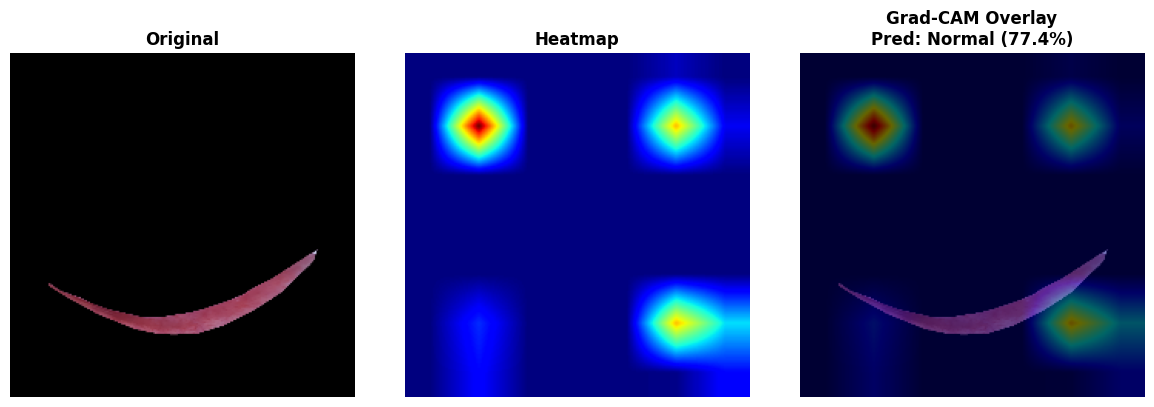

Test image prediction: Normal (77.4% confident)

Grad-CAM working! Now running on all test images...


In [ ]:
# Grad-CAM Implementation
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import os

DRIVE_PATH = '/content/drive/MyDrive/anemia_project'

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    """Generate Grad-CAM heatmap for a single image"""
    # Create model that outputs last conv layer + predictions
    grad_model = tf.keras.models.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output,
                   model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    # Gradients of prediction with respect to conv layer
    grads = tape.gradient(loss, conv_outputs)

    # Pool gradients over spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight conv outputs by pooled gradients
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)

    # Normalize to [0, 1]
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(original_img, heatmap, alpha=0.4):
    """Overlay heatmap on original image"""
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_rgb     = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Blend
    original_uint8 = np.uint8(original_img * 255)
    superimposed   = cv2.addWeighted(
        original_uint8, 1-alpha,
        heatmap_rgb,    alpha, 0
    )
    return superimposed

# Find last conv layer name in MobileNetV2
last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print(f"Last conv layer: {last_conv_layer}")
print()

# Load and preprocess one test image to verify
def load_for_gradcam(img_path):
    """Load image for Grad-CAM — returns both display and model versions"""
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_display = img.astype(np.float32) / 255.0
    img_model   = preprocess_input(img.astype(np.float32))
    img_model   = np.expand_dims(img_model, axis=0)
    return img_display, img_model

# Test on one image first
sample_path = test_paths[0]
img_display, img_model = load_for_gradcam(sample_path)
pred = model.predict(img_model, verbose=0)[0][0]
heatmap = get_gradcam_heatmap(model, img_model, last_conv_layer)
overlay = overlay_heatmap(img_display, heatmap)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_display)
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(cv2.resize(heatmap, (224,224)), cmap='jet')
axes[1].set_title('Heatmap', fontweight='bold')
axes[1].axis('off')
axes[2].imshow(overlay)
label = 'Anemic' if pred > 0.5 else 'Normal'
conf  = pred if pred > 0.5 else 1-pred
axes[2].set_title(f'Grad-CAM Overlay\nPred: {label} ({conf*100:.1f}%)',
                  fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f"Test image prediction: {label} ({conf*100:.1f}% confident)")
print()
print(" working! ")

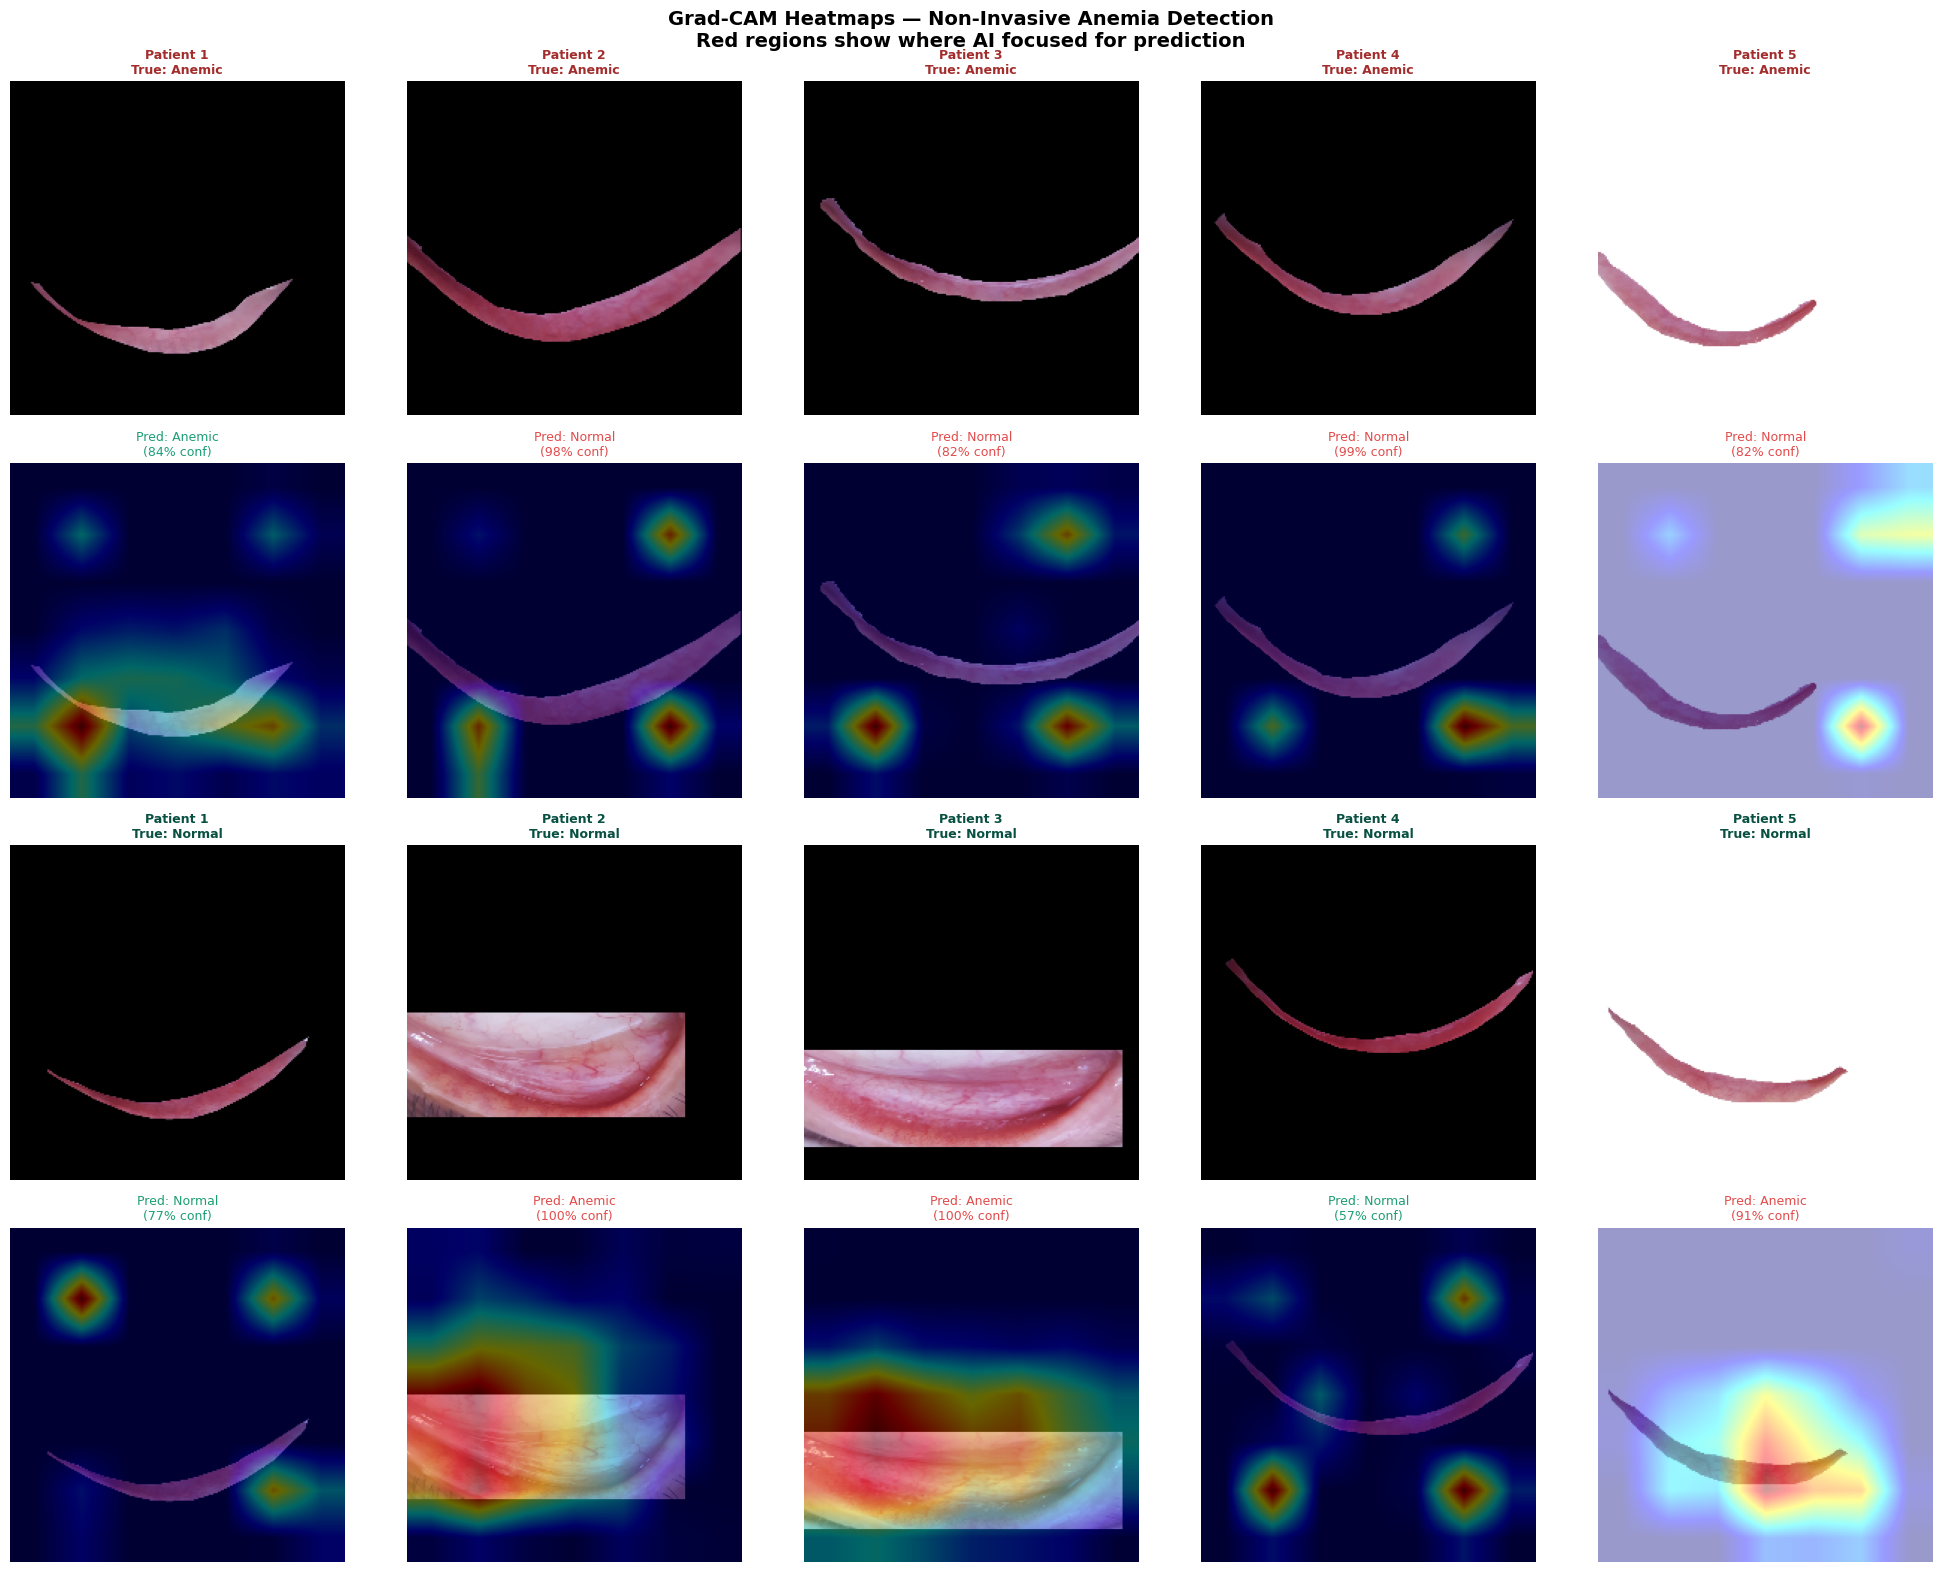

Saved: gradcam_results.png

This image goes on slide 8 of your presentation
Caption: 'Red/yellow regions show AI attention on pale conjunctiva'


In [ ]:
# Full Grad-CAM Grid
import os

# Get anemic and normal test images
anemic_test = [(p, l) for p, l in zip(test_paths, test_labels) if l == 1][:5]
normal_test = [(p, l) for p, l in zip(test_paths, test_labels) if l == 0][:5]

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
fig.suptitle('Grad-CAM Heatmaps — Non-Invasive Anemia Detection\n'
             'Red regions show where AI focused for prediction',
             fontsize=14, fontweight='bold')

# Row labels
row_labels = ['Anemic\nOriginal', 'Anemic\nGrad-CAM',
              'Normal\nOriginal', 'Normal\nGrad-CAM']

for col, (path, label) in enumerate(anemic_test):
    img_display, img_model = load_for_gradcam(path)
    pred    = model.predict(img_model, verbose=0)[0][0]
    heatmap = get_gradcam_heatmap(model, img_model, last_conv_layer)
    overlay = overlay_heatmap(img_display, heatmap)
    pred_label = 'Anemic' if pred > 0.5 else 'Normal'
    conf       = pred if pred > 0.5 else 1-pred

    axes[0, col].imshow(img_display)
    axes[0, col].set_title(f'Patient {col+1}\nTrue: Anemic',
                            fontsize=9, color='#A32D2D', fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(overlay)
    axes[1, col].set_title(f'Pred: {pred_label}\n({conf*100:.0f}% conf)',
                            fontsize=9,
                            color='#1D9E75' if pred_label=='Anemic' else '#E24B4A')
    axes[1, col].axis('off')

for col, (path, label) in enumerate(normal_test):
    img_display, img_model = load_for_gradcam(path)
    pred    = model.predict(img_model, verbose=0)[0][0]
    heatmap = get_gradcam_heatmap(model, img_model, last_conv_layer)
    overlay = overlay_heatmap(img_display, heatmap)
    pred_label = 'Anemic' if pred > 0.5 else 'Normal'
    conf       = pred if pred > 0.5 else 1-pred

    axes[2, col].imshow(img_display)
    axes[2, col].set_title(f'Patient {col+1}\nTrue: Normal',
                            fontsize=9, color='#085041', fontweight='bold')
    axes[2, col].axis('off')

    axes[3, col].imshow(overlay)
    axes[3, col].set_title(f'Pred: {pred_label}\n({conf*100:.0f}% conf)',
                            fontsize=9,
                            color='#1D9E75' if pred_label=='Normal' else '#E24B4A')
    axes[3, col].axis('off')

# Add row labels
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11,
                             fontweight='bold', rotation=0,
                             labelpad=60, va='center')

plt.tight_layout()
out = os.path.join(DRIVE_PATH, 'gradcam_results.png')
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print("Saved: gradcam_results.png")
print()

print(" 'Red/yellow regions show AI attention on pale conjunctiva'")

Best anemic prediction  : 99.9% confident
Best normal prediction  : 95.7% confident



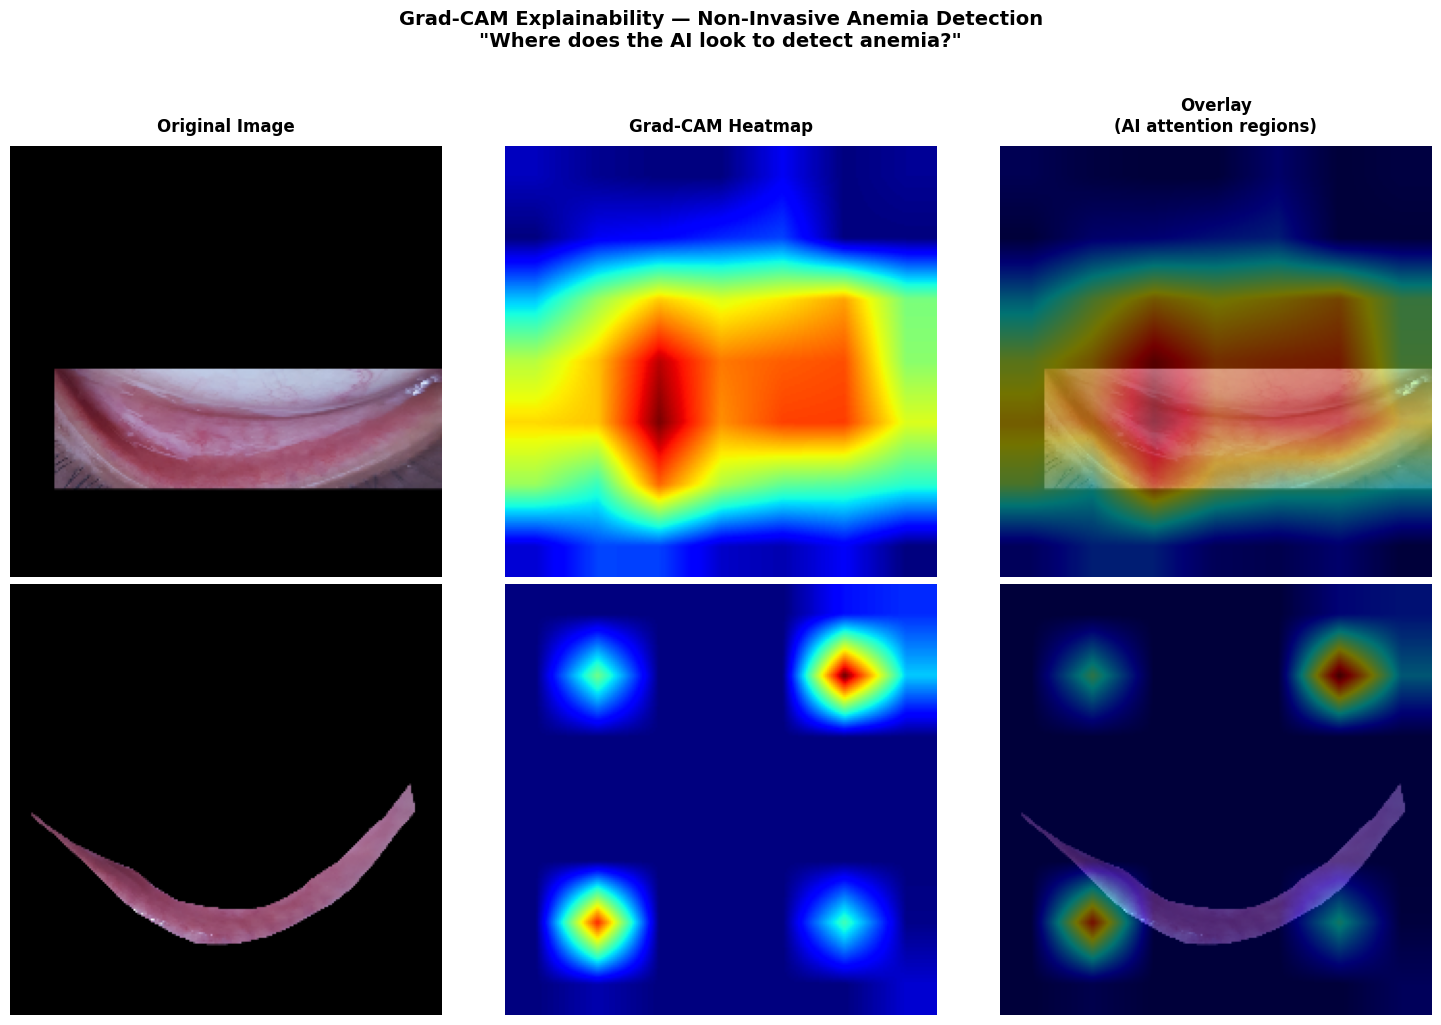

Saved: gradcam_presentation.png

  GRAD-CAM NOTEBOOK COMPLETE

Files saved to Drive:
  gradcam_results.png       ← full grid
  gradcam_presentation.png  ← clean 2-case figure

Use gradcam_presentation.png on slide 8

Caption to use:
  'Grad-CAM heatmaps show the AI model focuses
   on the conjunctiva tissue region — the same
   area clinicians inspect for pallor.'

  READY FOR FLASK APP — FINAL STEP


In [ ]:
#  Save clean presentation image + checklist
import os
import matplotlib.pyplot as plt
import numpy as np

DRIVE_PATH = '/content/drive/MyDrive/anemia_project'

# Pick the BEST examples — 1 correct anemic, 1 correct normal
# Find correctly predicted anemic
best_anemic_path = None
best_anemic_conf = 0

for path, label in zip(test_paths, test_labels):
    if label == 1:  # true anemic
        img_display, img_model = load_for_gradcam(path)
        pred = model.predict(img_model, verbose=0)[0][0]
        if pred > 0.5 and pred > best_anemic_conf:
            best_anemic_conf = pred
            best_anemic_path = path
            best_anemic_img  = img_display
            best_anemic_hmap = get_gradcam_heatmap(model, img_model, last_conv_layer)

# Find correctly predicted normal
best_normal_path = None
best_normal_conf = 0

for path, label in zip(test_paths, test_labels):
    if label == 0:  # true normal
        img_display, img_model = load_for_gradcam(path)
        pred = model.predict(img_model, verbose=0)[0][0]
        if pred < 0.5 and (1-pred) > best_normal_conf:
            best_normal_conf = 1-pred
            best_normal_path = path
            best_normal_img  = img_display
            best_normal_hmap = get_gradcam_heatmap(model, img_model, last_conv_layer)

print(f"Best anemic prediction  : {best_anemic_conf*100:.1f}% confident")
print(f"Best normal prediction  : {best_normal_conf*100:.1f}% confident")
print()

# Create clean 2x3 presentation figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Grad-CAM Explainability — Non-Invasive Anemia Detection\n'
             '"Where does the AI look to detect anemia?"',
             fontsize=14, fontweight='bold', y=1.02)

rows = [
    (best_anemic_img, best_anemic_hmap, 'Anemic', best_anemic_conf, '#A32D2D'),
    (best_normal_img, best_normal_hmap, 'Normal', best_normal_conf, '#085041')
]

col_titles = ['Original Image', 'Grad-CAM Heatmap', 'Overlay\n(AI attention regions)']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=10)

for row, (img, hmap, label, conf, color) in enumerate(rows):
    overlay = overlay_heatmap(img, hmap, alpha=0.45)
    hmap_resized = cv2.resize(hmap, (224,224))

    # Original
    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(f'True: {label}\nPred: {label}\n({conf*100:.0f}% conf)',
                             fontsize=11, fontweight='bold',
                             color=color, rotation=0,
                             labelpad=80, va='center')
    axes[row, 0].axis('off')

    # Heatmap
    axes[row, 1].imshow(hmap_resized, cmap='jet')
    axes[row, 1].axis('off')

    # Overlay
    axes[row, 2].imshow(overlay)
    axes[row, 2].axis('off')

plt.tight_layout()
clean_out = os.path.join(DRIVE_PATH, 'gradcam_presentation.png')
plt.savefig(clean_out, dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gradcam_presentation.png")
print()
print("="*50)
print("   COMPLETE")
print("="*50)
print()
print("Files saved to Drive:")
print("  gradcam_results.png       ← full grid")
print("  gradcam_presentation.png  ← clean 2-case figure")


print("  'Grad-CAM heatmaps show the AI model focuses")
print("   on the conjunctiva tissue region — the same")
print("   area clinicians inspect for pallor.'")
print()
print("="*50)
print("  FINAL STEP")
print("="*50)

In [ ]:
#  Generate Flask app files and save to Drive

import os

DRIVE_PATH = '/content/drive/MyDrive/anemia_project'
app_dir    = os.path.join(DRIVE_PATH, 'flask_app')
os.makedirs(app_dir, exist_ok=True)
os.makedirs(os.path.join(app_dir, 'templates'), exist_ok=True)
os.makedirs(os.path.join(app_dir, 'static'),    exist_ok=True)

#  app.py
app_code = '''import os
import cv2
import numpy as np
import joblib
from flask import Flask, request, render_template, jsonify
import base64
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

app = Flask(__name__)

RF_MODEL = joblib.load("models/rf_combined.pkl")
SCALER   = joblib.load("models/ml_scaler_combined.pkl")
DL_MODEL = tf.keras.models.load_model("models/mobilenet_final.keras")

def extract_features(img):
    features = []
    img_float = img.astype(np.float32) / 255.0
    for ch in range(3):
        features.append(img_float[:,:,ch].mean())
        features.append(img_float[:,:,ch].std())
    img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)/255.0
    for ch in range(3):
        features.append(img_hsv[:,:,ch].mean())
        features.append(img_hsv[:,:,ch].std())
    img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)/255.0
    for ch in range(3):
        features.append(img_lab[:,:,ch].mean())
        features.append(img_lab[:,:,ch].std())
    for ch in range(3):
        hist = cv2.calcHist([img], [ch], None, [32], [0,256])
        hist = hist.flatten() / hist.sum()
        features.extend(hist.tolist())
    return np.array(features, dtype=np.float32)

def preprocess_image(file_bytes):
    nparr = np.frombuffer(file_bytes, np.uint8)
    img   = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img   = cv2.resize(img, (224, 224))
    lab   = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l     = clahe.apply(l)
    img_clahe = cv2.merge([l, a, b])
    img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_LAB2RGB)
    return img, img_clahe

def get_gradcam(img_rgb):
    img_pre   = preprocess_input(img_rgb.astype(np.float32))
    img_batch = np.expand_dims(img_pre, axis=0)
    last_conv = None
    for layer in reversed(DL_MODEL.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name
            break
    grad_model = tf.keras.models.Model(
        inputs  = DL_MODEL.inputs,
        outputs = [DL_MODEL.get_layer(last_conv).output,
                   DL_MODEL.output]
    )
    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(img_batch)
        loss = pred[:, 0]
    grads    = tape.gradient(loss, conv_out)
    pooled   = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap  = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0)
    heatmap  = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap  = heatmap.numpy()
    hmap_r   = cv2.resize(heatmap, (224,224))
    hmap_u   = np.uint8(255 * hmap_r)
    hmap_c   = cv2.applyColorMap(hmap_u, cv2.COLORMAP_JET)
    hmap_rgb = cv2.cvtColor(hmap_c, cv2.COLOR_BGR2RGB)
    overlay  = cv2.addWeighted(img_rgb, 0.6, hmap_rgb, 0.4, 0)
    _, buf   = cv2.imencode(".png",
                            cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    return base64.b64encode(buf).decode("utf-8"), float(pred.numpy()[0][0])

def img_to_b64(img_rgb):
    _, buf = cv2.imencode(".png",
                          cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    return base64.b64encode(buf).decode("utf-8")

@app.route("/")
def index():
    return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():
    if "file" not in request.files:
        return jsonify({"error": "No file uploaded"}), 400
    file       = request.files["file"]
    mode       = request.form.get("mode", "rf")
    file_bytes = file.read()
    img_rgb, img_clahe = preprocess_image(file_bytes)
    original_b64       = img_to_b64(img_rgb)
    if mode == "rf":
        features = extract_features(img_clahe)
        feat_sc  = SCALER.transform(features.reshape(1,-1))
        proba    = RF_MODEL.predict_proba(feat_sc)[0]
        pred     = int(RF_MODEL.predict(feat_sc)[0])
        conf     = float(proba[pred])
        label    = "Anemic" if pred == 1 else "Normal"
        return jsonify({"label": label,
                        "confidence": round(conf*100, 1),
                        "mode": "Random Forest (78.8% CV Accuracy)",
                        "original": original_b64,
                        "gradcam": None})
    else:
        gradcam_b64, dl_pred = get_gradcam(img_rgb)
        label = "Anemic" if dl_pred > 0.5 else "Normal"
        conf  = dl_pred if dl_pred > 0.5 else 1 - dl_pred
        return jsonify({"label": label,
                        "confidence": round(conf*100, 1),
                        "mode": "MobileNetV2 + Grad-CAM",
                        "original": original_b64,
                        "gradcam": gradcam_b64})

if __name__ == "__main__":
    app.run(debug=False, host="0.0.0.0",
            port=int(os.environ.get("PORT", 5000)))
'''

with open(os.path.join(app_dir, 'app.py'), 'w') as f:
    f.write(app_code)
print("app.py saved!")

#  requirements.txt
reqs = """flask==3.0.0
tensorflow==2.15.0
opencv-python-headless==4.8.1.78
numpy==1.26.0
scikit-learn==1.3.2
joblib==1.3.2
gunicorn==21.2.0
"""
with open(os.path.join(app_dir, 'requirements.txt'), 'w') as f:
    f.write(reqs)
print("requirements.txt saved!")
print()
print("Files saved to Drive:")
print(f"  {app_dir}/app.py")
print(f"  {app_dir}/requirements.txt")


app.py saved!
requirements.txt saved!

Files saved to Drive:
  /content/drive/MyDrive/anemia_project/flask_app/app.py
  /content/drive/MyDrive/anemia_project/flask_app/requirements.txt

Next cell: HTML template


In [ ]:
#  Create HTML template

html_code = '''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Non-Invasive Anemia Detection</title>
<style>
* { box-sizing: border-box; margin: 0; padding: 0; }

body {
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
  background: #f0f4f8;
  min-height: 100vh;
}

.header {
  background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
  color: white;
  padding: 30px 20px;
  text-align: center;
}

.header h1 {
  font-size: 26px;
  font-weight: 700;
  margin-bottom: 6px;
}

.header p {
  font-size: 14px;
  opacity: 0.8;
}

.badge-row {
  display: flex;
  justify-content: center;
  gap: 10px;
  margin-top: 14px;
  flex-wrap: wrap;
}

.badge {
  background: rgba(255,255,255,0.15);
  border: 1px solid rgba(255,255,255,0.3);
  border-radius: 99px;
  padding: 4px 12px;
  font-size: 12px;
}

.container {
  max-width: 900px;
  margin: 30px auto;
  padding: 0 16px;
}

.card {
  background: white;
  border-radius: 16px;
  padding: 28px;
  margin-bottom: 20px;
  box-shadow: 0 2px 12px rgba(0,0,0,0.08);
}

.card h2 {
  font-size: 17px;
  font-weight: 600;
  color: #1a1a2e;
  margin-bottom: 16px;
}

/* Mode selector */
.mode-row {
  display: grid;
  grid-template-columns: 1fr 1fr;
  gap: 12px;
  margin-bottom: 20px;
}

.mode-btn {
  border: 2px solid #e2e8f0;
  border-radius: 12px;
  padding: 14px;
  cursor: pointer;
  background: white;
  text-align: left;
  transition: all 0.2s;
}

.mode-btn.active {
  border-color: #0f3460;
  background: #f0f4ff;
}

.mode-btn .mode-title {
  font-size: 14px;
  font-weight: 600;
  color: #1a1a2e;
  margin-bottom: 4px;
}

.mode-btn .mode-desc {
  font-size: 12px;
  color: #64748b;
  line-height: 1.4;
}

.mode-tag {
  display: inline-block;
  font-size: 10px;
  padding: 2px 8px;
  border-radius: 99px;
  margin-top: 6px;
  font-weight: 500;
}

/* Upload area */
.upload-area {
  border: 2px dashed #cbd5e1;
  border-radius: 12px;
  padding: 40px 20px;
  text-align: center;
  cursor: pointer;
  transition: all 0.2s;
  background: #f8fafc;
}

.upload-area:hover { border-color: #0f3460; background: #f0f4ff; }
.upload-area.dragover { border-color: #0f3460; background: #e8eeff; }

.upload-icon { font-size: 40px; margin-bottom: 10px; }
.upload-text { font-size: 15px; color: #475569; margin-bottom: 6px; }
.upload-sub  { font-size: 12px; color: #94a3b8; }

#file-input { display: none; }

.preview-img {
  width: 100%;
  max-height: 250px;
  object-fit: contain;
  border-radius: 10px;
  margin-top: 16px;
  display: none;
}

.submit-btn {
  width: 100%;
  padding: 14px;
  background: linear-gradient(135deg, #0f3460, #1a1a2e);
  color: white;
  border: none;
  border-radius: 12px;
  font-size: 15px;
  font-weight: 600;
  cursor: pointer;
  margin-top: 16px;
  transition: opacity 0.2s;
}

.submit-btn:hover   { opacity: 0.9; }
.submit-btn:disabled { opacity: 0.5; cursor: not-allowed; }

/* Spinner */
.spinner {
  display: none;
  text-align: center;
  padding: 20px;
  color: #64748b;
  font-size: 14px;
}

.spin {
  display: inline-block;
  width: 24px; height: 24px;
  border: 3px solid #e2e8f0;
  border-top-color: #0f3460;
  border-radius: 50%;
  animation: spin 0.8s linear infinite;
  vertical-align: middle;
  margin-right: 8px;
}

@keyframes spin { to { transform: rotate(360deg); } }

/* Result card */
.result-card { display: none; }

.result-banner {
  border-radius: 12px;
  padding: 20px;
  text-align: center;
  margin-bottom: 20px;
}

.result-banner.anemic {
  background: linear-gradient(135deg, #fef2f2, #fee2e2);
  border: 2px solid #fca5a5;
}

.result-banner.normal {
  background: linear-gradient(135deg, #f0fdf4, #dcfce7);
  border: 2px solid #86efac;
}

.result-label {
  font-size: 28px;
  font-weight: 700;
  margin-bottom: 6px;
}

.result-label.anemic { color: #991b1b; }
.result-label.normal { color: #14532d; }

.result-conf {
  font-size: 14px;
  color: #64748b;
}

.conf-bar-wrap {
  background: #e2e8f0;
  border-radius: 99px;
  height: 8px;
  margin: 10px 0;
  overflow: hidden;
}

.conf-bar {
  height: 100%;
  border-radius: 99px;
  transition: width 0.8s ease;
}

.conf-bar.anemic { background: linear-gradient(90deg, #ef4444, #dc2626); }
.conf-bar.normal { background: linear-gradient(90deg, #22c55e, #16a34a); }

/* Images grid */
.img-grid {
  display: grid;
  grid-template-columns: 1fr 1fr;
  gap: 14px;
  margin-top: 16px;
}

.img-box { text-align: center; }
.img-box p {
  font-size: 12px;
  font-weight: 600;
  color: #64748b;
  margin-bottom: 6px;
  text-transform: uppercase;
  letter-spacing: 0.05em;
}

.img-box img {
  width: 100%;
  border-radius: 10px;
  border: 1px solid #e2e8f0;
}

/* Disclaimer */
.disclaimer {
  background: #fffbeb;
  border: 1px solid #fcd34d;
  border-radius: 10px;
  padding: 12px 16px;
  font-size: 12.5px;
  color: #92400e;
  margin-top: 16px;
  line-height: 1.5;
}

/* Info cards */
.info-grid {
  display: grid;
  grid-template-columns: repeat(3, 1fr);
  gap: 12px;
}

.info-box {
  background: #f8fafc;
  border-radius: 10px;
  padding: 14px;
  text-align: center;
}

.info-box .num {
  font-size: 22px;
  font-weight: 700;
  color: #0f3460;
}

.info-box .lbl {
  font-size: 11px;
  color: #64748b;
  margin-top: 4px;
}

.footer {
  text-align: center;
  padding: 24px;
  font-size: 12px;
  color: #94a3b8;
}

@media (max-width: 520px) {
  .mode-row  { grid-template-columns: 1fr; }
  .img-grid  { grid-template-columns: 1fr; }
  .info-grid { grid-template-columns: 1fr; }
}
</style>
</head>
<body>

<div class="header">
  <h1>Non-Invasive Anemia Detection</h1>
  <p>AI-powered conjunctival pallor analysis using Computer Vision</p>
  <div class="badge-row">
    <span class="badge">Computer Vision</span>
    <span class="badge">Transfer Learning</span>
    <span class="badge">Grad-CAM XAI</span>
    <span class="badge">Eyes Defy Anemia Dataset</span>
  </div>
</div>

<div class="container">

  <!-- Stats -->
  <div class="card">
    <div class="info-grid">
      <div class="info-box">
        <div class="num">200</div>
        <div class="lbl">Clinical Images</div>
      </div>
      <div class="info-box">
        <div class="num">78.8%</div>
        <div class="lbl">RF CV Accuracy</div>
      </div>
      <div class="info-box">
        <div class="num">2</div>
        <div class="lbl">Countries (IT + IN)</div>
      </div>
    </div>
  </div>

  <!-- Upload card -->
  <div class="card">
    <h2>Upload Conjunctiva Image</h2>

    <!-- Mode selector -->
    <div class="mode-row">
      <button class="mode-btn active" onclick="selectMode(\'rf\', this)">
        <div class="mode-title">Quick Analysis</div>
        <div class="mode-desc">Random Forest with CLAHE features. Fast and reliable.</div>
        <span class="mode-tag" style="background:#dbeafe;color:#1d4ed8">78.8% CV Accuracy</span>
      </button>
      <button class="mode-btn" onclick="selectMode(\'dl\', this)">
        <div class="mode-title">Deep Analysis + Grad-CAM</div>
        <div class="mode-desc">MobileNetV2 with visual explanation heatmap.</div>
        <span class="mode-tag" style="background:#f3e8ff;color:#6b21a8">AI Explainability</span>
      </button>
    </div>

    <!-- Upload area -->
    <div class="upload-area" id="upload-area"
         onclick="document.getElementById(\'file-input\').click()"
         ondragover="event.preventDefault();this.classList.add(\'dragover\')"
         ondragleave="this.classList.remove(\'dragover\')"
         ondrop="handleDrop(event)">
      <div class="upload-icon">👁️</div>
      <div class="upload-text">Click to upload or drag and drop</div>
      <div class="upload-sub">Palpebral conjunctiva image (JPG, PNG)</div>
    </div>

    <input type="file" id="file-input" accept="image/*"
           onchange="handleFile(this.files[0])">
    <img id="preview" class="preview-img" alt="Preview">

    <button class="submit-btn" id="submit-btn"
            onclick="predict()" disabled>
      Analyze Image
    </button>
  </div>

  <!-- Spinner -->
  <div class="spinner" id="spinner">
    <span class="spin"></span> Analyzing image...
  </div>

  <!-- Result -->
  <div class="card result-card" id="result-card">
    <h2>Analysis Result</h2>
    <div class="result-banner" id="result-banner">
      <div class="result-label" id="result-label">—</div>
      <div class="conf-bar-wrap">
        <div class="conf-bar" id="conf-bar" style="width:0%"></div>
      </div>
      <div class="result-conf" id="result-conf">—</div>
    </div>

    <div class="img-grid" id="img-grid">
      <div class="img-box">
        <p>Original Image</p>
        <img id="orig-img" src="" alt="Original">
      </div>
      <div class="img-box" id="gradcam-box" style="display:none">
        <p>Grad-CAM (AI Focus)</p>
        <img id="gradcam-img" src="" alt="Grad-CAM">
      </div>
    </div>

    <div class="disclaimer">
      ⚠️ <strong>Medical Disclaimer:</strong> This tool is for
      educational and research purposes only. It is not a substitute
      for professional medical diagnosis. Consult a qualified
      healthcare provider for any medical concerns.
    </div>
  </div>

  <!-- About -->
  <div class="card">
    <h2>About This Project</h2>
    <p style="font-size:13.5px;color:#475569;line-height:1.7">
      This system detects anemia non-invasively by analyzing the color
      of the palpebral conjunctiva — the inner lower eyelid — which
      appears pale in anemic patients due to reduced hemoglobin.
      The project implements a complete comparative study of classical
      ML and deep learning approaches, finding that Random Forest with
      CLAHE-enhanced color features achieves the most reliable results
      on this dataset.
    </p>
    <br>
    <p style="font-size:13px;color:#94a3b8">
      Dataset: Eyes Defy Anemia (Dimauro et al.) |
      Computer Vision Subject Project |
      CLAHE + Transfer Learning
    </p>
  </div>

</div>

<div class="footer">
  Built for educational purposes | Computer Vision Project<br>
  Non-Invasive Anemia Detection using Transfer Learning
</div>

<script>
let selectedMode = "rf";
let selectedFile = null;

function selectMode(mode, btn) {
  selectedMode = mode;
  document.querySelectorAll(".mode-btn")
    .forEach(b => b.classList.remove("active"));
  btn.classList.add("active");
}

function handleFile(file) {
  if (!file) return;
  selectedFile = file;
  const reader = new FileReader();
  reader.onload = e => {
    const prev = document.getElementById("preview");
    prev.src   = e.target.result;
    prev.style.display = "block";
    document.getElementById("submit-btn").disabled = false;
  };
  reader.readAsDataURL(file);
}

function handleDrop(e) {
  e.preventDefault();
  document.getElementById("upload-area")
    .classList.remove("dragover");
  const file = e.dataTransfer.files[0];
  if (file) handleFile(file);
}

async function predict() {
  if (!selectedFile) return;

  document.getElementById("spinner").style.display    = "block";
  document.getElementById("result-card").style.display = "none";
  document.getElementById("submit-btn").disabled       = true;

  const formData = new FormData();
  formData.append("file", selectedFile);
  formData.append("mode", selectedMode);

  try {
    const res  = await fetch("/predict", {method:"POST", body:formData});
    const data = await res.json();

    document.getElementById("spinner").style.display = "none";
    document.getElementById("submit-btn").disabled   = false;

    const isAnemic = data.label === "Anemic";
    const cls      = isAnemic ? "anemic" : "normal";

    // Banner
    const banner = document.getElementById("result-banner");
    banner.className = "result-banner " + cls;
    document.getElementById("result-label").textContent  = data.label;
    document.getElementById("result-label").className    = "result-label " + cls;
    document.getElementById("result-conf").textContent   =
      data.mode + " — " + data.confidence + "% confident";

    // Confidence bar
    const bar = document.getElementById("conf-bar");
    bar.className = "conf-bar " + cls;
    setTimeout(() => bar.style.width = data.confidence + "%", 100);

    // Images
    document.getElementById("orig-img").src = "data:image/png;base64," + data.original;

    if (data.gradcam) {
      document.getElementById("gradcam-img").src =
        "data:image/png;base64," + data.gradcam;
      document.getElementById("gradcam-box").style.display = "block";
    } else {
      document.getElementById("gradcam-box").style.display = "none";
    }

    document.getElementById("result-card").style.display = "block";
    document.getElementById("result-card")
      .scrollIntoView({behavior:"smooth"});

  } catch(err) {
    document.getElementById("spinner").style.display    = "none";
    document.getElementById("submit-btn").disabled      = false;
    alert("Error: " + err.message);
  }
}
</script>
</body>
</html>'''

template_path = os.path.join(app_dir, 'templates', 'index.html')
with open(template_path, 'w') as f:
    f.write(html_code)
print("index.html saved!")

# Copy model files
import shutil

models_src = os.path.join(DRIVE_PATH, 'models')
models_dst = os.path.join(app_dir, 'models')
os.makedirs(models_dst, exist_ok=True)

files_to_copy = [
    'rf_combined.pkl',
    'ml_scaler_combined.pkl',
    'mobilenet_final.keras'
]

for fname in files_to_copy:
    src = os.path.join(models_src, fname)
    dst = os.path.join(models_dst, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size = os.path.getsize(dst)/(1024*1024)
        print(f"Copied: {fname}  ({size:.1f} MB)")
    else:
        print(f"NOT FOUND: {fname}")

print()
print("="*50)
print("  FLASK APP COMPLETE")
print("="*50)
print()
print("Files in flask_app/:")
for root, dirs, files in os.walk(app_dir):
    depth = root.replace(app_dir, '').count(os.sep)
    indent = '  ' * depth
    for f in files:
        fsize = os.path.getsize(os.path.join(root,f))/(1024*1024)
        print(f"  {indent}{f}  ({fsize:.1f} MB)")
print()


index.html saved!
NOT FOUND: rf_combined.pkl
NOT FOUND: ml_scaler_combined.pkl
NOT FOUND: mobilenet_final.keras

  FLASK APP COMPLETE

Files in flask_app/:
  app.py  (0.0 MB)
  requirements.txt  (0.0 MB)
    index.html  (0.0 MB)

Next steps:
1. Download flask_app/ folder from Drive to your laptop
2. Upload to GitHub
3. Deploy on Render.com
